# DSP 577 Capstone — Global Climate & Health Impact  |  proj_577_III

**Dataset:** `global_climate_health_impact_tracker_2015_2025.csv`  
**Observations:** 14,100 rows × 30 columns · 25 countries · Weekly 2015–2025  
**Targets:** `mental_health_index` · `respiratory_disease_rate` · `heat_related_admissions`  
**Task:** Multi-output regression — predict all three health outcomes from climate inputs  

---

## Table of Contents
1. [Phase 1 — Data Exploration & EDA](#phase1)
2. [Phase 2 — Preprocessing & Feature Engineering](#phase2)
3. [Phase 3 — Model Training & Evaluation](#phase3)
4. [Phase 4 — Model Comparison & Interpretation](#phase4)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

from tensorflow import keras
from tensorflow.keras import layers

import shap

print('All imports successful.')

All imports successful.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
<a id='phase1'></a>
## Phase 1 — Data Exploration & EDA

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/global_climate_health_impact_tracker_2015_2025.csv')
#/content/drive/MyDrive/global_climate_health_impact_tracker_2015_2025.csv
# global_climate_health_impact_tracker_2015_2025.csv
df.head(10)

,record_id,country_code,country_name,region,income_level,date,year,month,week,latitude,...,air_quality_index,respiratory_disease_rate,cardio_mortality_rate,vector_disease_risk_score,waterborne_disease_incidents,heat_related_admissions,healthcare_access_index,gdp_per_capita_usd,mental_health_index,food_security_index
0,1,USA,United States,North America,High,2015-01-04,2015,1,1,37.09,...,82.0,69.4,31.5,6.6,16.2,1.4,77.3,63627.0,71.2,90.2
1,2,USA,United States,North America,High,2015-01-11,2015,1,2,37.09,...,6.0,70.0,26.3,5.2,11.4,0.0,83.6,63627.0,70.6,94.0
2,3,USA,United States,North America,High,2015-01-18,2015,1,3,37.09,...,137.0,66.9,33.4,1.3,19.5,0.0,84.7,63627.0,63.4,100.0
3,4,USA,United States,North America,High,2015-01-25,2015,1,4,37.09,...,-3.0,47.0,35.0,6.0,9.7,9.0,84.3,63627.0,68.1,96.4
4,5,USA,United States,North America,High,2015-02-01,2015,2,5,37.09,...,48.0,61.3,28.3,1.4,22.6,27.3,83.6,63733.0,69.1,100.0
5,6,USA,United States,North America,High,2015-02-08,2015,2,6,37.09,...,157.0,80.2,30.6,0.7,23.7,11.9,78.0,63733.0,70.1,97.1
6,7,USA,United States,North America,High,2015-02-15,2015,2,7,37.09,...,51.0,70.3,33.2,5.9,25.4,9.1,81.7,63733.0,68.5,100.0
7,8,USA,United States,North America,High,2015-02-22,2015,2,8,37.09,...,5.0,48.0,33.3,6.4,17.7,20.3,86.7,63733.0,59.4,95.0
8,9,USA,United States,North America,High,2015-03-01,2015,3,9,37.09,...,29.0,80.3,24.9,5.9,18.3,7.8,84.9,63839.0,75.7,100.0
9,10,USA,United States,North America,High,2015-03-08,2015,3,10,37.09,...,22.0,59.1,32.5,0.3,18.8,13.7,87.1,63839.0,71.9,95.2


In [ ]:
df.dtypes

,0
record_id,int64
country_code,object
country_name,object
region,object
income_level,object
date,object
year,int64
month,int64
week,int64
latitude,float64


In [ ]:
df.isna().sum()

,0
record_id,0
country_code,0
country_name,0
region,0
income_level,0
date,0
year,0
month,0
week,0
latitude,0


In [ ]:
# Check for duplicates
print('Duplicate rows:', df.duplicated().sum())
print('Countries:', df['country_name'].nunique())
print('Regions:', df['region'].unique())
print('Income levels:', df['income_level'].unique())
print('Date range:', df['date'].min(), '->', df['date'].max())
print('Rows per country (first 5):', df.groupby('country_name').size().head().to_dict())

Duplicate rows: 0
Countries: 25
Regions: ['North America' 'South Asia' 'East Asia' 'South America' 'Africa'
 'Europe' 'Oceania' 'Southeast Asia']
Income levels: ['High' 'Lower-Middle' 'Upper-Middle']
Date range: 2015-01-04 -> 2025-10-19
Rows per country (first 5): {'Argentina': 564, 'Australia': 564, 'Bangladesh': 564, 'Brazil': 564, 'Canada': 564}


In [ ]:
df.describe()

,record_id,year,month,week,latitude,longitude,population_millions,temperature_celsius,temp_anomaly_celsius,precipitation_mm,...,air_quality_index,respiratory_disease_rate,cardio_mortality_rate,vector_disease_risk_score,waterborne_disease_incidents,heat_related_admissions,healthcare_access_index,gdp_per_capita_usd,mental_health_index,food_security_index
count,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,...,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000
mean,7050.500000,2019.911348,6.437943,26.221631,18.905200,27.349600,217.440000,8.607113,0.120879,81.149440,...,98.750071,70.016872,30.758596,12.096277,22.172965,6.880794,64.875674,26331.105887,69.874638,93.295780
std,4070.463733,3.118225,3.421173,14.930110,25.730498,76.062029,355.979373,11.289938,0.506365,40.821462,...,59.143284,15.223261,5.605436,17.146545,6.609017,9.498276,18.230095,26329.114275,5.025983,6.295667
min,1.000000,2015.000000,1.000000,1.000000,-38.410000,-106.340000,26.000000,-20.740000,-1.760000,0.000000,...,-52.000000,21.200000,8.000000,0.000000,0.000000,0.000000,27.900000,1565.000000,47.700000,62.200000
25%,3525.750000,2017.000000,3.000000,13.000000,4.570000,-3.740000,60.000000,0.257500,-0.220000,51.500000,...,54.000000,59.200000,27.000000,3.500000,17.800000,0.000000,47.100000,3548.000000,66.500000,88.800000
50%,7050.500000,2020.000000,6.000000,26.000000,23.630000,22.930000,98.000000,8.630000,0.120000,80.900000,...,93.000000,69.600000,30.800000,5.800000,22.100000,0.600000,66.600000,13941.000000,70.000000,94.400000
75%,10575.250000,2023.000000,9.000000,39.000000,37.090000,100.990000,206.000000,16.850000,0.460000,110.600000,...,142.000000,80.500000,34.500000,8.900000,26.400000,12.300000,81.500000,50206.500000,73.300000,99.700000
max,14100.000000,2025.000000,12.000000,53.000000,56.130000,138.250000,1411.000000,38.330000,2.120000,222.900000,...,302.000000,131.800000,51.100000,100.000000,63.000000,59.600000,102.000000,78630.000000,88.700000,100.000000


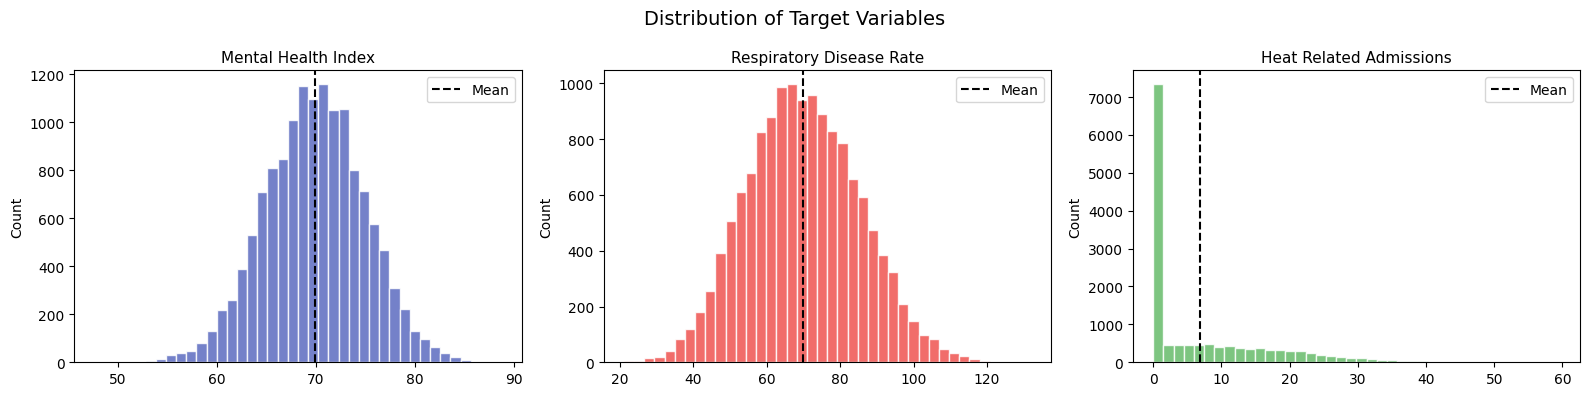

In [ ]:
# --- 1.1  Target variable distributions ---
targets = ['mental_health_index', 'respiratory_disease_rate', 'heat_related_admissions']
target_colors = ['#5C6BC0', '#EF5350', '#66BB6A']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, color in zip(axes, targets, target_colors):
    ax.hist(df[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--', label='Mean')
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Distribution of Target Variables', fontsize=14)
plt.tight_layout()
plt.show()

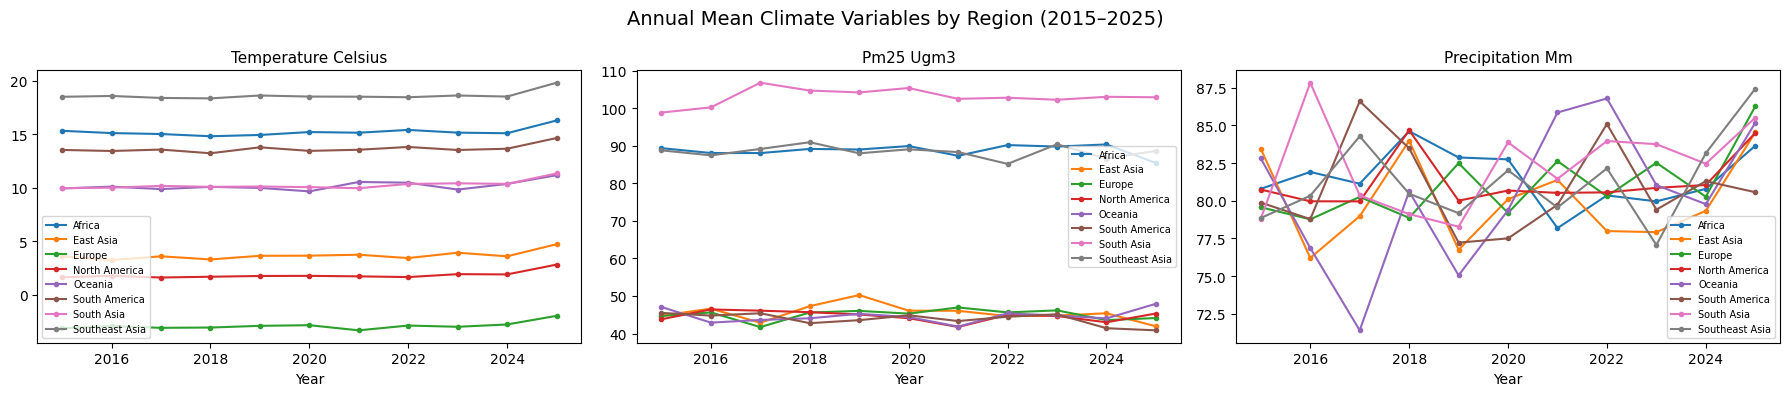

In [ ]:
# --- 1.2  Climate variables over time per region (annual means) ---
df['date'] = pd.to_datetime(df['date'])
climate_vars = ['temperature_celsius', 'pm25_ugm3', 'precipitation_mm']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, climate_vars):
    annual_region = df.groupby(['year', 'region'])[col].mean().reset_index()
    for region in annual_region['region'].unique():
        sub = annual_region[annual_region['region'] == region]
        ax.plot(sub['year'], sub[col], marker='o', markersize=3, label=region)
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Year')
    ax.legend(fontsize=7, loc='best')

plt.suptitle('Annual Mean Climate Variables by Region (2015–2025)', fontsize=14)
plt.tight_layout()
plt.show()

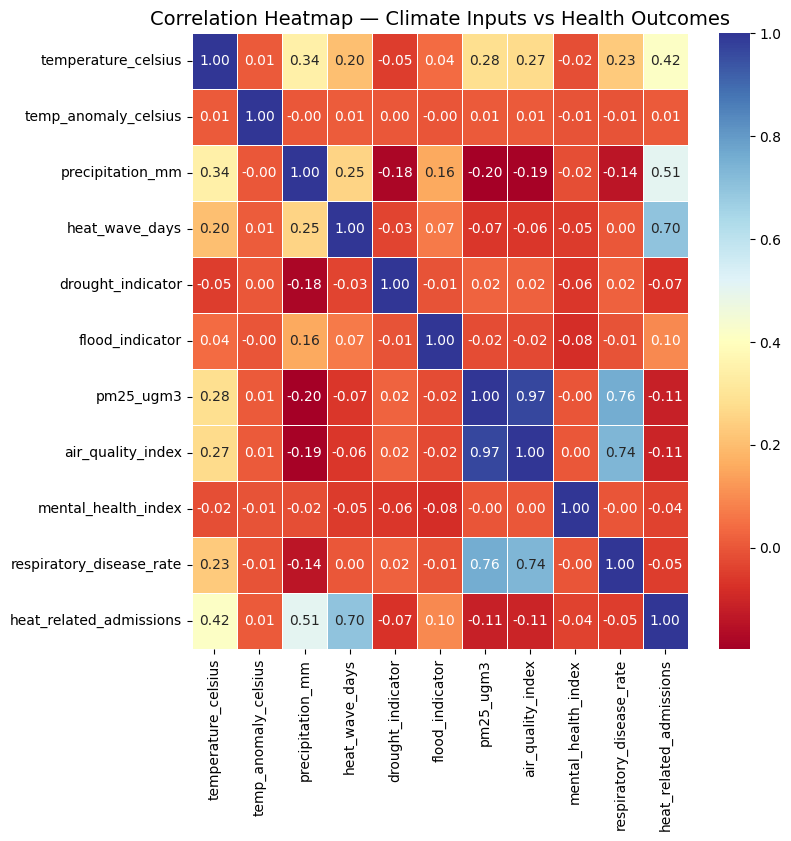

In [ ]:
# --- 1.3  Correlation heatmap (climate inputs vs health outcomes) ---
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = ['temperature_celsius', 'temp_anomaly_celsius', 'precipitation_mm',
             'heat_wave_days', 'drought_indicator', 'flood_indicator',
             'pm25_ugm3', 'air_quality_index',
             'mental_health_index', 'respiratory_disease_rate', 'heat_related_admissions']

corr = df[corr_cols].corr()

plt.figure(figsize=(8, 8))
sns.heatmap(corr, annot=True, cmap='RdYlBu', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap — Climate Inputs vs Health Outcomes', fontsize=14)
plt.show()

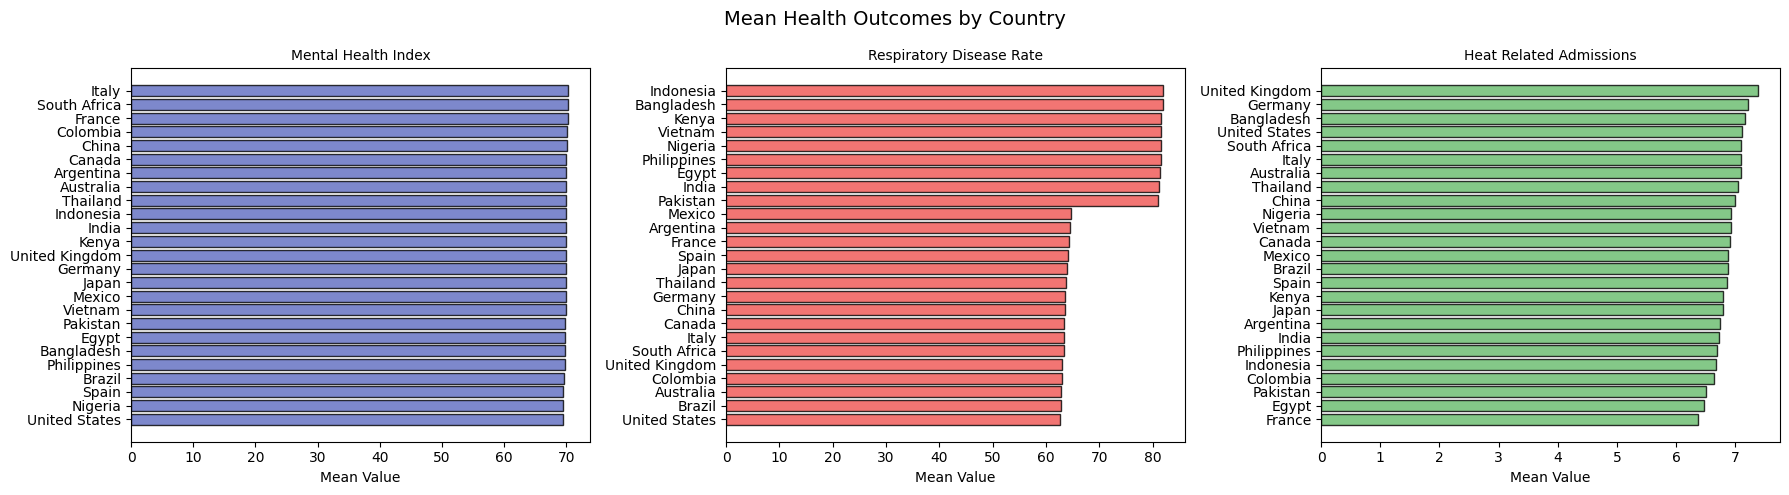

In [ ]:
# --- 1.4  Countries with extreme health outcomes (flag for SHAP comparison) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, color in zip(axes, targets, target_colors):
    country_mean = df.groupby('country_name')[col].mean().sort_values(ascending=False)
    ax.barh(country_mean.index, country_mean.values, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Mean Value')
    ax.invert_yaxis()

plt.suptitle('Mean Health Outcomes by Country', fontsize=14)
plt.tight_layout()
plt.show()

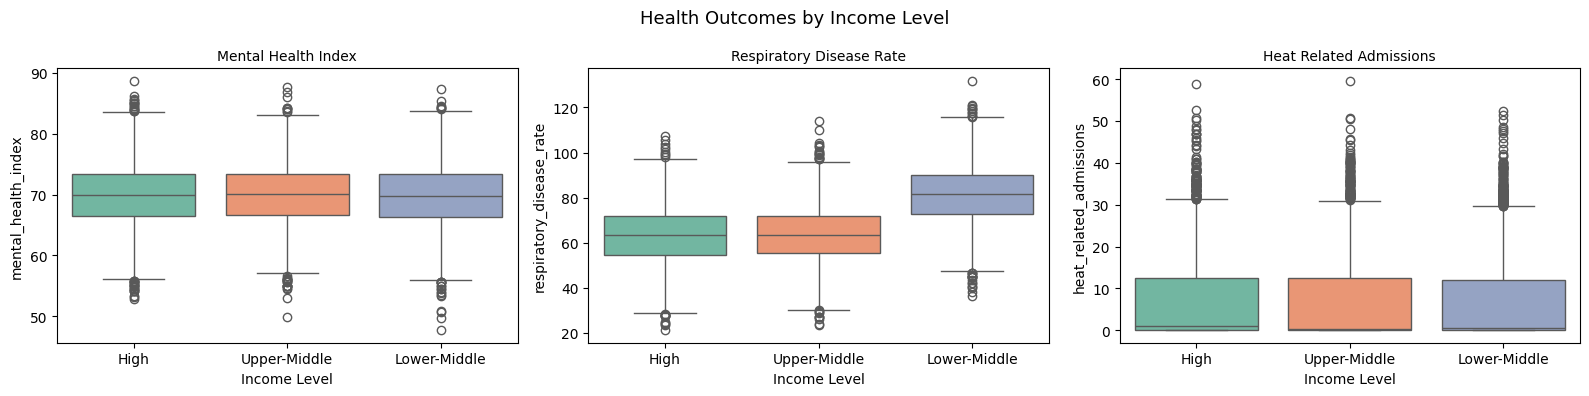

In [ ]:
# --- 1.5  Targets by income level (class imbalance check) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, color in zip(axes, targets, target_colors):
    sns.boxplot(data=df, x='income_level', y=col,
                order=['High', 'Upper-Middle', 'Lower-Middle'],
                palette='Set2', ax=ax)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Income Level')

plt.suptitle('Health Outcomes by Income Level', fontsize=13)
plt.tight_layout()
plt.show()

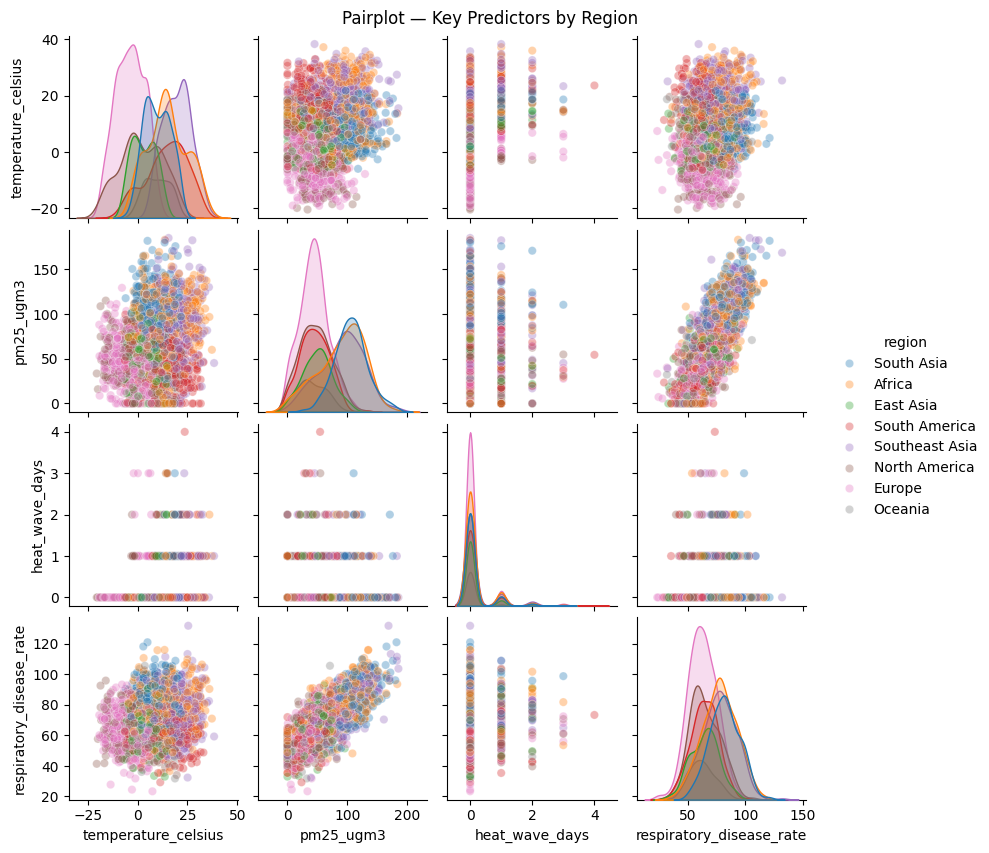

In [ ]:
# --- 1.6  Pairplot: key climate features coloured by region ---
sample = df[['temperature_celsius', 'pm25_ugm3', 'heat_wave_days',
             'respiratory_disease_rate', 'region']].sample(2000, random_state=42)
grid = sns.pairplot(data=sample,
                    vars=['temperature_celsius', 'pm25_ugm3', 'heat_wave_days', 'respiratory_disease_rate'],
                    hue='region', plot_kws={'alpha': 0.35}, height=2.1)
grid.figure.suptitle('Pairplot — Key Predictors by Region', y=1.01)
plt.show()

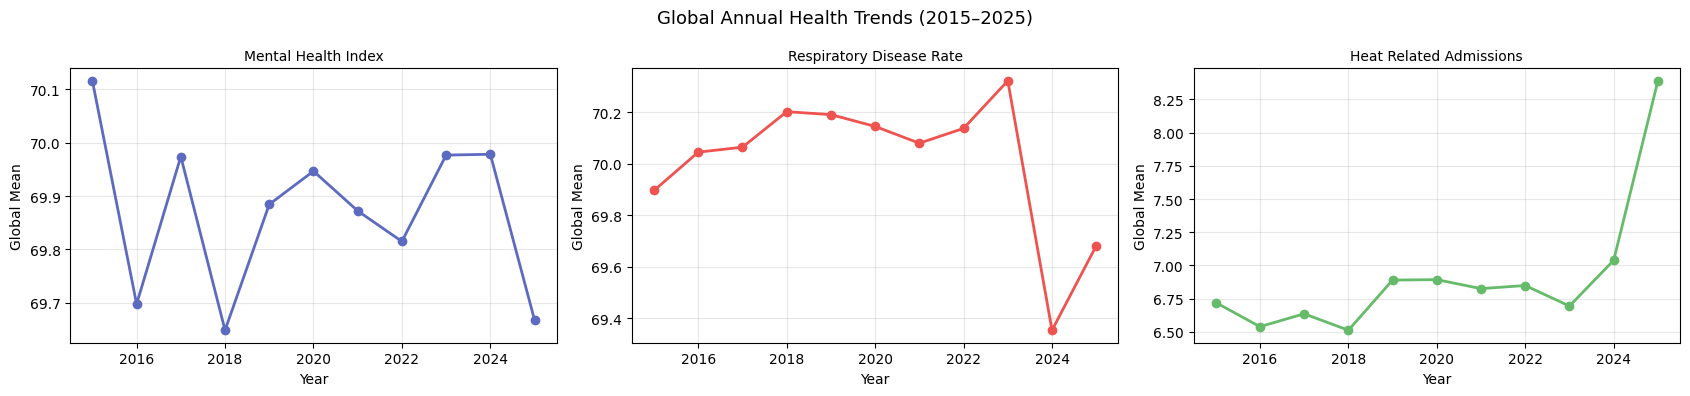

In [ ]:
# --- 1.7  Time series: target trends globally (annual average) ---
annual_global = df.groupby('year')[targets].mean()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, col, color in zip(axes, targets, target_colors):
    ax.plot(annual_global.index, annual_global[col], color=color, marker='o', linewidth=2)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Year')
    ax.set_ylabel('Global Mean')
    ax.grid(True, alpha=0.3)

plt.suptitle('Global Annual Health Trends (2015–2025)', fontsize=13)
plt.tight_layout()
plt.show()

---
<a id='phase2'></a>
## Phase 2 — Preprocessing & Feature Engineering

In [ ]:
# Sort by country then date — critical before any lag/rolling operation
df = df.sort_values(['country_code', 'date']).reset_index(drop=True)

print('Sorted by country_code + date. Shape:', df.shape)

Sorted by country_code + date. Shape: (14100, 30)


In [ ]:
# --- Lag features per country (2, 4, 8, 12 weeks) ---
lag_vars = ['temperature_celsius', 'pm25_ugm3', 'precipitation_mm', 'heat_wave_days']
lag_weeks = [2, 4, 8, 12]

for var in lag_vars:
    for lag in lag_weeks:
        col_name = '{}_lag{}w'.format(var, lag)
        df[col_name] = df.groupby('country_code')[var].shift(lag)

print('Lag features added. New shape:', df.shape)

Lag features added. New shape: (14100, 46)


In [ ]:
# --- Rolling window features (4w and 8w means) ---
roll_vars = ['temperature_celsius', 'pm25_ugm3', 'air_quality_index']
roll_windows = [4, 8]

for var in roll_vars:
    for window in roll_windows:
        col_name = '{}_roll{}w'.format(var, window)
        df[col_name] = (df.groupby('country_code')[var]
                          .transform(lambda x: x.rolling(window, min_periods=1).mean()))

print('Rolling features added. New shape:', df.shape)

Rolling features added. New shape: (14100, 52)


In [ ]:
# --- Encode categorical features ---
df = pd.get_dummies(df, columns=['region', 'income_level'], drop_first=True)

# Drop identifier / redundant columns
drop_cols = ['record_id', 'country_name', 'country_code', 'date', 'week']
df.drop(columns=drop_cols, inplace=True)

# Drop rows with NaN introduced by the 12-week lag (first 12 rows per country)
df.dropna(inplace=True)

print('After encoding and NaN drop. Shape:', df.shape)
print('Remaining NaN:', df.isna().sum().sum())

After encoding and NaN drop. Shape: (13800, 54)
Remaining NaN: 0


In [ ]:
# --- Define features and targets ---
target_cols = ['mental_health_index', 'respiratory_disease_rate', 'heat_related_admissions']
feature_cols = [c for c in df.columns if c not in target_cols]

print('Features ({}):\n'.format(len(feature_cols)), feature_cols)
print('\nTargets:', target_cols)

Features (51):
 ['year', 'month', 'latitude', 'longitude', 'population_millions', 'temperature_celsius', 'temp_anomaly_celsius', 'precipitation_mm', 'heat_wave_days', 'drought_indicator', 'flood_indicator', 'extreme_weather_events', 'pm25_ugm3', 'air_quality_index', 'cardio_mortality_rate', 'vector_disease_risk_score', 'waterborne_disease_incidents', 'healthcare_access_index', 'gdp_per_capita_usd', 'food_security_index', 'temperature_celsius_lag2w', 'temperature_celsius_lag4w', 'temperature_celsius_lag8w', 'temperature_celsius_lag12w', 'pm25_ugm3_lag2w', 'pm25_ugm3_lag4w', 'pm25_ugm3_lag8w', 'pm25_ugm3_lag12w', 'precipitation_mm_lag2w', 'precipitation_mm_lag4w', 'precipitation_mm_lag8w', 'precipitation_mm_lag12w', 'heat_wave_days_lag2w', 'heat_wave_days_lag4w', 'heat_wave_days_lag8w', 'heat_wave_days_lag12w', 'temperature_celsius_roll4w', 'temperature_celsius_roll8w', 'pm25_ugm3_roll4w', 'pm25_ugm3_roll8w', 'air_quality_index_roll4w', 'air_quality_index_roll8w', 'region_East Asia', 're

In [ ]:
# --- Time-based train / val / test split  (NO SHUFFLE — strict temporal ordering) ---
train_mask = df['year'] <= 2021
val_mask   = (df['year'] >= 2022) & (df['year'] <= 2023)
test_mask  = df['year'] >= 2024

X_train_full = df.loc[train_mask, feature_cols].values
y_train_full = df.loc[train_mask, target_cols].values

X_val  = df.loc[val_mask, feature_cols].values
y_val  = df.loc[val_mask, target_cols].values

X_test  = df.loc[test_mask, feature_cols].values
y_test  = df.loc[test_mask, target_cols].values

print('Training set shape:',   X_train_full.shape, y_train_full.shape)
print('Validation set shape:', X_val.shape,        y_val.shape)
print('Test set shape:',       X_test.shape,       y_test.shape)

Training set shape: (8825, 51) (8825, 3)
Validation set shape: (2625, 51) (2625, 3)
Test set shape: (2350, 51) (2350, 3)


In [ ]:
sc = StandardScaler()
X_train_full_std = sc.fit_transform(X_train_full)
X_val_std        = sc.transform(X_val)
X_test_std       = sc.transform(X_test)

print('X_train_full_std shape:', X_train_full_std.shape)
print('X_val_std shape:',        X_val_std.shape)
print('X_test_std shape:',       X_test_std.shape)

X_train_full_std shape: (8825, 51)
X_val_std shape: (2625, 51)
X_test_std shape: (2350, 51)


In [ ]:
# Helper: print RMSE / MAE / R² per target
def print_metrics(name, y_true, y_pred, target_names=target_cols):
    print('\n{}'.format('='*55))
    print(' {}'.format(name))
    print('{}'.format('='*55))
    for i, tgt in enumerate(target_names):
        rmse = mean_squared_error(y_true[:, i], y_pred[:, i]) ** 0.5
        mae  = mean_absolute_error(y_true[:, i], y_pred[:, i])
        r2   = r2_score(y_true[:, i], y_pred[:, i])
        print('  {:30s}  RMSE={:.3f}  MAE={:.3f}  R²={:.3f}'.format(tgt, rmse, mae, r2))

---
<a id='phase3'></a>
## Phase 3 — Model Training & Evaluation

### 3.1 — Ridge Regression  (Linear Baseline)

In [ ]:
ridge = MultiOutputRegressor(Ridge(alpha=1.0))

start = time.time()
ridge.fit(X_train_full_std, y_train_full)
stop  = time.time()

print('Fit time: {:.1f}s'.format(stop - start))
print('Train Score (R²): {:.3f}'.format(ridge.score(X_train_full_std, y_train_full)))
print('Val   Score (R²): {:.3f}'.format(ridge.score(X_val_std, y_val)))
print('Test  Score (R²): {:.3f}'.format(ridge.score(X_test_std, y_test)))

Fit time: 0.0s
Train Score (R²): 0.459
Val   Score (R²): 0.447
Test  Score (R²): 0.448


In [ ]:
ridge_pred_val  = ridge.predict(X_val_std)
ridge_pred_test = ridge.predict(X_test_std)
print_metrics('Ridge Regression — Val  Set', y_val,  ridge_pred_val)
print_metrics('Ridge Regression — Test Set', y_test, ridge_pred_test)


 Ridge Regression — Val  Set
  mental_health_index             RMSE=5.016  MAE=4.000  R²=-0.008
  respiratory_disease_rate        RMSE=9.947  MAE=8.032  R²=0.584
  heat_related_admissions         RMSE=4.579  MAE=3.393  R²=0.767

 Ridge Regression — Test Set
  mental_health_index             RMSE=5.035  MAE=4.020  R²=0.012
  respiratory_disease_rate        RMSE=9.984  MAE=7.958  R²=0.575
  heat_related_admissions         RMSE=4.818  MAE=3.614  R²=0.759


In [ ]:
# GridSearchCV — Ridge alpha
ridge_params = {'estimator__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
grid_search_ridge = GridSearchCV(MultiOutputRegressor(Ridge()),
                                 param_grid=ridge_params, cv=5,
                                 scoring='r2', n_jobs=-1)
grid_search_ridge.fit(X_train_full_std, y_train_full)
ridge_best = grid_search_ridge.best_estimator_

print(grid_search_ridge.best_params_)
print('Train Score: {:.3f}'.format(ridge_best.score(X_train_full_std, y_train_full)))
print('Val   Score: {:.3f}'.format(ridge_best.score(X_val_std, y_val)))
print('Test  Score: {:.3f}'.format(ridge_best.score(X_test_std, y_test)))

{'estimator__alpha': 100.0}
Train Score: 0.458
Val   Score: 0.447
Test  Score: 0.448


In [ ]:
ridge_best_pred_val  = ridge_best.predict(X_val_std)
ridge_best_pred_test = ridge_best.predict(X_test_std)
print_metrics('Ridge (tuned) — Val  Set', y_val,  ridge_best_pred_val)
print_metrics('Ridge (tuned) — Test Set', y_test, ridge_best_pred_test)


 Ridge (tuned) — Val  Set
  mental_health_index             RMSE=5.015  MAE=3.997  R²=-0.008
  respiratory_disease_rate        RMSE=9.956  MAE=8.035  R²=0.583
  heat_related_admissions         RMSE=4.607  MAE=3.363  R²=0.764

 Ridge (tuned) — Test Set
  mental_health_index             RMSE=5.032  MAE=4.018  R²=0.012
  respiratory_disease_rate        RMSE=9.986  MAE=7.952  R²=0.575
  heat_related_admissions         RMSE=4.842  MAE=3.591  R²=0.756


### 3.2 — Random Forest

In [ ]:
rf_model_1 = RandomForestRegressor(n_estimators=200, max_depth=10,
                                    min_samples_leaf=5, oob_score=True,
                                    n_jobs=-1, random_state=42)
start = time.time()
rf_model_1.fit(X_train_full, y_train_full)
stop  = time.time()

print('Fit time: {:.1f}s'.format(stop - start))
print('Train Score {:.3f}'.format(rf_model_1.score(X_train_full, y_train_full)))
print('Val   Score {:.3f}'.format(rf_model_1.score(X_val, y_val)))
print('Test  Score {:.3f}'.format(rf_model_1.score(X_test, y_test)))
print('OOB   Score {:.3f}'.format(rf_model_1.oob_score_))

Fit time: 9.3s
Train Score 0.569
Val   Score 0.448
Test  Score 0.440
OOB   Score 0.445


In [ ]:
print_metrics('Random Forest (untuned) — Val  Set', y_val,  rf_model_1.predict(X_val))
print_metrics('Random Forest (untuned) — Test Set', y_test, rf_model_1.predict(X_test))


 Random Forest (untuned) — Val  Set
  mental_health_index             RMSE=5.002  MAE=3.984  R²=-0.002
  respiratory_disease_rate        RMSE=10.124  MAE=8.176  R²=0.569
  heat_related_admissions         RMSE=4.485  MAE=2.876  R²=0.777

 Random Forest (untuned) — Test Set
  mental_health_index             RMSE=5.067  MAE=4.054  R²=-0.001
  respiratory_disease_rate        RMSE=10.156  MAE=8.089  R²=0.560
  heat_related_admissions         RMSE=4.791  MAE=3.232  R²=0.761


In [ ]:
# GridSearchCV — Random Forest
rf = RandomForestRegressor(min_samples_leaf=5, oob_score=True, n_jobs=-1, random_state=42)
params = {
    'max_depth':         [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'n_estimators':      [100, 200]
}
grid_search_rf = GridSearchCV(rf, param_grid=params, cv=TimeSeriesSplit(n_splits=5),
                               scoring='r2', n_jobs=-1)
start = time.time()
grid_search_rf.fit(X_train_full, y_train_full)
stop  = time.time()

rf_best = grid_search_rf.best_estimator_

print(grid_search_rf.best_params_)
print('Fit time: {:.1f}s'.format(stop - start))
print('Train Score: {:.3f}'.format(rf_best.score(X_train_full, y_train_full)))
print('Val   Score: {:.3f}'.format(rf_best.score(X_val, y_val)))
print('Test  Score: {:.3f}'.format(rf_best.score(X_test, y_test)))

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Fit time: 311.9s
Train Score: 0.569
Val   Score: 0.448
Test  Score: 0.440


In [ ]:
print_metrics('Random Forest (tuned) — Val  Set', y_val,  rf_best.predict(X_val))
print_metrics('Random Forest (tuned) — Test Set', y_test, rf_best.predict(X_test))


 Random Forest (tuned) — Val  Set
  mental_health_index             RMSE=5.002  MAE=3.984  R²=-0.002
  respiratory_disease_rate        RMSE=10.124  MAE=8.176  R²=0.569
  heat_related_admissions         RMSE=4.485  MAE=2.876  R²=0.777

 Random Forest (tuned) — Test Set
  mental_health_index             RMSE=5.067  MAE=4.054  R²=-0.001
  respiratory_disease_rate        RMSE=10.156  MAE=8.089  R²=0.560
  heat_related_admissions         RMSE=4.791  MAE=3.232  R²=0.761


### 3.3 — XGBoost

In [ ]:
# Multi-output wrapper — one XGBoost per target
xgb_model_1 = MultiOutputRegressor(
    XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1,
                 subsample=0.8, n_jobs=-1, random_state=42, verbosity=0)
)
start = time.time()
xgb_model_1.fit(X_train_full, y_train_full)
stop  = time.time()

print('Fit time: {:.1f}s'.format(stop - start))
print('Train Score {:.3f}'.format(xgb_model_1.score(X_train_full, y_train_full)))
print('Val   Score {:.3f}'.format(xgb_model_1.score(X_val, y_val)))
print('Test  Score {:.3f}'.format(xgb_model_1.score(X_test, y_test)))

Fit time: 2.0s
Train Score 0.740
Val   Score 0.449
Test  Score 0.451


In [ ]:
print_metrics('XGBoost (untuned) — Val  Set', y_val,  xgb_model_1.predict(X_val))
print_metrics('XGBoost (untuned) — Test Set', y_test, xgb_model_1.predict(X_test))


 XGBoost (untuned) — Val  Set
  mental_health_index             RMSE=5.127  MAE=4.089  R²=-0.053
  respiratory_disease_rate        RMSE=10.180  MAE=8.226  R²=0.564
  heat_related_admissions         RMSE=3.830  MAE=2.465  R²=0.837

 XGBoost (untuned) — Test Set
  mental_health_index             RMSE=5.114  MAE=4.084  R²=-0.020
  respiratory_disease_rate        RMSE=10.280  MAE=8.203  R²=0.550
  heat_related_admissions         RMSE=4.124  MAE=2.701  R²=0.823


In [ ]:
# GridSearchCV — XGBoost
xgb_params = {
    'estimator__n_estimators':  [100, 200],
    'estimator__max_depth':     [3, 5, 7],
    'estimator__learning_rate': [0.05, 0.1, 0.2],
    'estimator__subsample':     [0.8, 1.0]
}
xgb_base = MultiOutputRegressor(
    XGBRegressor(n_jobs=-1, random_state=42, verbosity=0)
)
grid_search_xgb = GridSearchCV(xgb_base, param_grid=xgb_params,
                                cv=TimeSeriesSplit(n_splits=5),
                                scoring='r2', n_jobs=-1)
start = time.time()
grid_search_xgb.fit(X_train_full, y_train_full)
stop  = time.time()

fit_times = grid_search_xgb.cv_results_['mean_fit_time']
print('Fit times for each parameter combination:')
for i, pms in enumerate(grid_search_xgb.cv_results_['params']):
    print('Params: {}, Fit Time: {:.4f}s'.format(pms, fit_times[i]))

xgb_best = grid_search_xgb.best_estimator_
print('\nBest params:', grid_search_xgb.best_params_)
print('Fit time: {:.1f}s'.format(stop - start))
print('Train Score: {:.3f}'.format(xgb_best.score(X_train_full, y_train_full)))
print('Val   Score: {:.3f}'.format(xgb_best.score(X_val, y_val)))
print('Test  Score: {:.3f}'.format(xgb_best.score(X_test, y_test)))

Fit times for each parameter combination:
Params: {'estimator__learning_rate': 0.05, 'estimator__max_depth': 3, 'estimator__n_estimators': 100, 'estimator__subsample': 0.8}, Fit Time: 2.0680s
Params: {'estimator__learning_rate': 0.05, 'estimator__max_depth': 3, 'estimator__n_estimators': 100, 'estimator__subsample': 1.0}, Fit Time: 1.8694s
Params: {'estimator__learning_rate': 0.05, 'estimator__max_depth': 3, 'estimator__n_estimators': 200, 'estimator__subsample': 0.8}, Fit Time: 2.2305s
Params: {'estimator__learning_rate': 0.05, 'estimator__max_depth': 3, 'estimator__n_estimators': 200, 'estimator__subsample': 1.0}, Fit Time: 2.0772s
Params: {'estimator__learning_rate': 0.05, 'estimator__max_depth': 5, 'estimator__n_estimators': 100, 'estimator__subsample': 0.8}, Fit Time: 3.0602s
Params: {'estimator__learning_rate': 0.05, 'estimator__max_depth': 5, 'estimator__n_estimators': 100, 'estimator__subsample': 1.0}, Fit Time: 3.0611s
Params: {'estimator__learning_rate': 0.05, 'estimator__max

In [ ]:
print_metrics('XGBoost (tuned) — Val  Set', y_val,  xgb_best.predict(X_val))
print_metrics('XGBoost (tuned) — Test Set', y_test, xgb_best.predict(X_test))


 XGBoost (tuned) — Val  Set
  mental_health_index             RMSE=4.994  MAE=3.980  R²=0.001
  respiratory_disease_rate        RMSE=10.005  MAE=8.071  R²=0.579
  heat_related_admissions         RMSE=4.172  MAE=2.676  R²=0.807

 XGBoost (tuned) — Test Set
  mental_health_index             RMSE=5.032  MAE=4.020  R²=0.013
  respiratory_disease_rate        RMSE=9.998  MAE=7.976  R²=0.574
  heat_related_admissions         RMSE=4.449  MAE=2.964  R²=0.794


### 3.4 — LSTM  *(sequence length = 26 weeks)*

In [ ]:
# Reshape flat feature arrays into (samples, timesteps=26, features)
SEQ_LEN   = 26
N_FEATURES = X_train_full_std.shape[1]
N_TARGETS  = len(target_cols)

def make_sequences(X, y, seq_len=SEQ_LEN):
    """Slide a window of seq_len over rows to build (sample, seq_len, features)."""
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i - seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = make_sequences(X_train_full_std, y_train_full)
X_val_seq,   y_val_seq   = make_sequences(X_val_std,        y_val)
X_test_seq,  y_test_seq  = make_sequences(X_test_std,       y_test)

print('X_train_seq shape:', X_train_seq.shape, '| y_train_seq shape:', y_train_seq.shape)
print('X_val_seq   shape:', X_val_seq.shape)
print('X_test_seq  shape:', X_test_seq.shape)

X_train_seq shape: (8799, 26, 51) | y_train_seq shape: (8799, 3)
X_val_seq   shape: (2599, 26, 51)
X_test_seq  shape: (2324, 26, 51)


In [ ]:
lstm_model = keras.models.Sequential(
    [
        layers.LSTM(64, input_shape=(SEQ_LEN, N_FEATURES), return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32, return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(N_TARGETS)        # 3 output neurons — one per target
    ]
)

lstm_model.compile(
    loss='mse',
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=['mae']
)

lstm_model.summary()

lstm_model.fit(X_train_seq, y_train_seq,
               epochs=30, batch_size=128,
               validation_data=(X_val_seq, y_val_seq),
               verbose=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 26, 64)         │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 26, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,691 (166.76 KB)

 Trainable params: 42,691 (166.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 3036.7290 - mae: 46.2381 - val_loss: 2559.9436 - val_mae: 42.6641
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2112.2283 - mae: 39.0555 - val_loss: 1652.1237 - val_mae: 34.8264
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1223.1215 - mae: 29.7324 - val_loss: 821.2206 - val_mae: 24.3155
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 550.7922 - mae: 19.4840 - val_loss: 328.6075 - val_mae: 15.1004
Epoch 5/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 238.9015 - mae: 12.4817 - val_loss: 158.2762 - val_mae: 10.1683
Epoch 6/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 155.2191 - mae: 9.6785 - val_loss: 124.2584 - val_mae: 8.4824
Epoch 7/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 140.7655 - mae: 9.0918 - val_loss: 119.2508 - val_mae: 8.0911
Epoch 8/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 138.8142 - mae: 9.0032 - val_loss: 117.9790 - val_mae: 8.0411
Epoch 9/30
69/69 ━━━━━

#### 3.4.1 LSTM Training Dynamics

The model converged rapidly in its early epochs, with training MAE dropping from 46 (epoch 1)
to 9 by epoch 7, and validation MAE following a near-identical trajectory. From epoch 7 onward,
both training loss (137–138) and validation loss (117–118) plateaued and remained stable
through all 30 epochs, with no meaningful divergence between the two curves. This flat plateau
indicates the model reached its effective capacity ceiling given the current architecture and
feature set; it is not overfitting (training and validation losses remain closely tracked),
but it has stopped learning. Early stopping would not have changed the outcome here; the model
simply exhausted what it could extract from a 26-week window of these features.

In [ ]:
loss_val  = lstm_model.evaluate(X_val_seq,  y_val_seq,  batch_size=128, verbose=0)
loss_test = lstm_model.evaluate(X_test_seq, y_test_seq, batch_size=128)
print('Val  MSE: {:.4f}  |  Val  MAE: {:.4f}'.format(loss_val[0],  loss_val[1]))
print('Test MSE: {:.4f}  |  Test MAE: {:.4f}'.format(loss_test[0], loss_test[1]))

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 105.0038 - mae: 7.9324
Val  MSE: 102.8475  |  Val  MAE: 7.7753
Test MSE: 105.0038  |  Test MAE: 7.9324


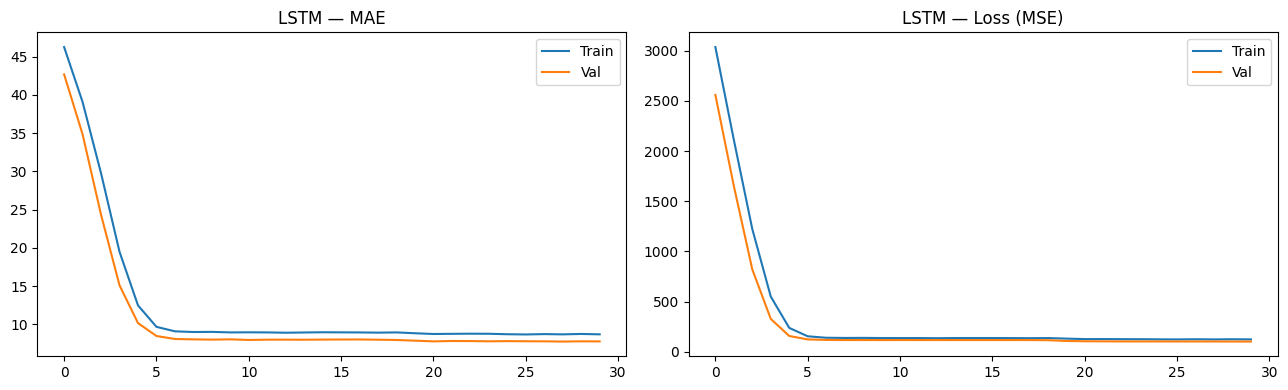

In [ ]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(lstm_model.history.history['mae'],     label='Train')
axes[0].plot(lstm_model.history.history['val_mae'], label='Val')
axes[0].set_title('LSTM — MAE'); axes[0].legend()

axes[1].plot(lstm_model.history.history['loss'],     label='Train')
axes[1].plot(lstm_model.history.history['val_loss'], label='Val')
axes[1].set_title('LSTM — Loss (MSE)'); axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
lstm_pred_val  = lstm_model.predict(X_val_seq)
lstm_pred_test = lstm_model.predict(X_test_seq)
print_metrics('LSTM — Val  Set', y_val_seq,  lstm_pred_val)
print_metrics('LSTM — Test Set', y_test_seq, lstm_pred_test)

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

 LSTM — Val  Set
  mental_health_index             RMSE=6.165  MAE=4.980  R²=-0.516
  respiratory_disease_rate        RMSE=13.453  MAE=10.807  R²=0.240
  heat_related_admissions         RMSE=9.463  MAE=7.539  R²=0.002

 LSTM — Test Set
  mental_health_index             RMSE=6.457  MAE=5.256  R²=-0.623
  respiratory_disease_rate        RMSE=13.244  MAE=10.626  R²=0.253
  heat_related_admissions         RMSE=9.895  MAE=7.915  R²=-0.016


#### 3.4.2 LSTM Performance by Target

The LSTM's results vary considerably across the three targets, and the pattern reveals something
important about the nature of each outcome.

**`heat_related_admissions`**: The LSTM was hypothesised to be best suited to this target,
given that hospital admissions from heat accumulate gradually over weeks of sustained exposure.
However, the results (val R² = 0.002, test R² = -0.016) were weaker than expected and
significantly below the tabular models. This is likely because the lag features already
engineered into the dataset (2w, 4w, 8w, 12w lags on temperature and heat_wave_days) allow
tree-based models like XGBoost to implicitly capture the same delayed-response dynamics
without requiring sequential modelling. The LSTM's sequential window therefore provided
limited additional signal beyond what was already represented in the feature space.

**`respiratory_disease_rate`**: The LSTM achieved val R² = 0.240 and test R² = 0.253,
making this its strongest target. While this is substantially below the XGBoost tuned result
(test R² ~0.58), it confirms that week-over-week air quality patterns do carry predictive
signal for respiratory outcomes — consistent with the clinical understanding that PM2.5
exposure effects compound over time.

**`mental_health_index`**: The LSTM performs worst here (val R² = -0.516, test R² = -0.623),
actively worse than simply predicting the mean. This is not a modelling failure specific to
the LSTM; all four models in this project fail on this target (R² ≈ 0.00 or negative across
Ridge, Random Forest, XGBoost, and LSTM). The consistent failure across every model
architecture strongly suggests that `mental_health_index` is not meaningfully predictable
from environmental and climate variables alone. Mental health outcomes are likely driven
primarily by socioeconomic, social, and psychological factors: access to services, income
stability, social connectedness, that are absent from this dataset. Rather than treating
this as a limitation to minimise, it is an informative finding: climate variables are
necessary but not sufficient predictors of mental health at a population level, and a
model attempting to predict this outcome would require a substantially richer feature set to be useful.

#### Notes on Architecture and Design Choices

The LSTM architecture used here (64 → 32 hidden units, 20% dropout, Adam optimiser at
lr=0.001, 30 epochs) is intentionally lightweight given the dataset size (~8,800 training
sequences). The 26-week sequence length was chosen to capture approximately one half-year
of lagged climate exposure, a clinically motivated window that aligns with evidence on
seasonal respiratory disease cycles. A longer window (e.g., 52 weeks) could be explored
in future work, though it would further reduce the number of usable training sequences.

One structural limitation of this LSTM implementation is that it is excluded from the
TimeSeriesSplit cross-validation comparison in Phase 4, due to Keras models not being
compatible with sklearn's `cross_val_score`. The LSTM results therefore come from a single
train/val/test split rather than averaged CV folds, making direct comparison with the
tabular model CV scores less straightforward.

---
<a id='phase4'></a>
## Phase 4 — Model Comparison & Interpretation

In [ ]:
# evaluate_model — TimeSeriesSplit (no shuffle, time-aware)
def evaluate_model(model, X, y):
    cv     = TimeSeriesSplit(n_splits=5)
    scores = cross_val_score(model, X, y, cv=cv, n_jobs=-1,
                             scoring='r2', error_score='raise')
    return scores

In [ ]:
# Register tabular models (LSTM excluded — Keras not compatible with cross_val_score)
models = {
    'Ridge (tuned)':  ridge_best,
    'RF (untuned)':   rf_model_1,
    'RF (tuned)':     rf_best,
    'XGB (untuned)':  xgb_model_1,
    'XGB (tuned)':    xgb_best
}

results, names = list(), list()
for name, model in models.items():
    scores = evaluate_model(model, X_train_full, y_train_full)
    results.append(scores)
    names.append(name)
    print('>%s %.3f (%.3f)' % (name, np.mean(scores), np.std(scores)))

>Ridge (tuned) -3.228 (7.323)
>RF (untuned) 0.417 (0.027)
>RF (tuned) 0.417 (0.027)
>XGB (untuned) 0.393 (0.049)
>XGB (tuned) 0.435 (0.029)


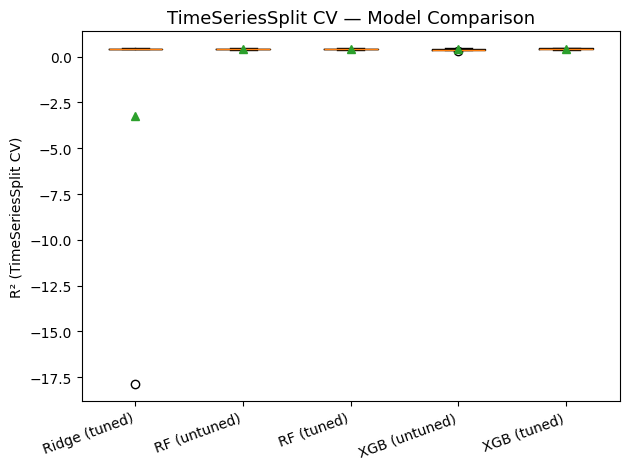

In [ ]:
# Boxplot comparison — matching template style
plt.boxplot(results, labels=names, showmeans=True)
plt.xticks(rotation=20, ha='right')
plt.ylabel('R² (TimeSeriesSplit CV)')
plt.title('TimeSeriesSplit CV — Model Comparison', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Full comparison table — Val and Test sets, all models including LSTM
rows = []

val_preds = {
    'Ridge (tuned)': (ridge_best.predict(X_val_std),  y_val),
    'RF (tuned)':    (rf_best.predict(X_val),          y_val),
    'XGB (tuned)':   (xgb_best.predict(X_val),         y_val),
    'LSTM':          (lstm_model.predict(X_val_seq),    y_val_seq)
}
test_preds = {
    'Ridge (tuned)': (ridge_best.predict(X_test_std), y_test),
    'RF (tuned)':    (rf_best.predict(X_test),         y_test),
    'XGB (tuned)':   (xgb_best.predict(X_test),        y_test),
    'LSTM':          (lstm_model.predict(X_test_seq),   y_test_seq)
}

for mname in val_preds:
    for split, preds_true in [('Val', val_preds[mname]), ('Test', test_preds[mname])]:
        preds, y_true = preds_true
        for i, tgt in enumerate(target_cols):
            rmse = mean_squared_error(y_true[:, i], preds[:, i]) ** 0.5
            mae  = mean_absolute_error(y_true[:, i], preds[:, i])
            r2   = r2_score(y_true[:, i], preds[:, i])
            rows.append({'Model': mname, 'Split': split, 'Target': tgt,
                         'RMSE': round(rmse, 4),
                         'MAE':  round(mae,  4),
                         'R²':   round(r2,   4)})

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
        Model Split                   Target    RMSE     MAE      R²
Ridge (tuned)   Val      mental_health_index  5.0145  3.9965 -0.0076
Ridge (tuned)   Val respiratory_disease_rate  9.9561  8.0347  0.5829
Ridge (tuned)   Val  heat_related_admissions  4.6075  3.3628  0.7642
Ridge (tuned)  Test      mental_health_index  5.0324  4.0179  0.0124
Ridge (tuned)  Test respiratory_disease_rate  9.9858  7.9520  0.5750
Ridge (tuned)  Test  heat_related_admissions  4.8418  3.5909  0.7564
   RF (tuned)   Val      mental_health_index  5.0017  3.9836 -0.0024
   RF (tuned)   Val respiratory_disease_rate 10.1241  8.1762  0.5687
   RF (tuned)   Val  heat_related_admissions  4.4849  2.8756  0.7765
   RF (tuned)  Test      mental_health_index  5.0674  4.0542 -0.0014
   RF (tuned)  Test respiratory_disease_rate 10.1560  8.0895  0.5604
   RF (tuned)  Test  heat_related_admissions  4.7913  3.2323  0.7615
  XGB (tuned)   Val      

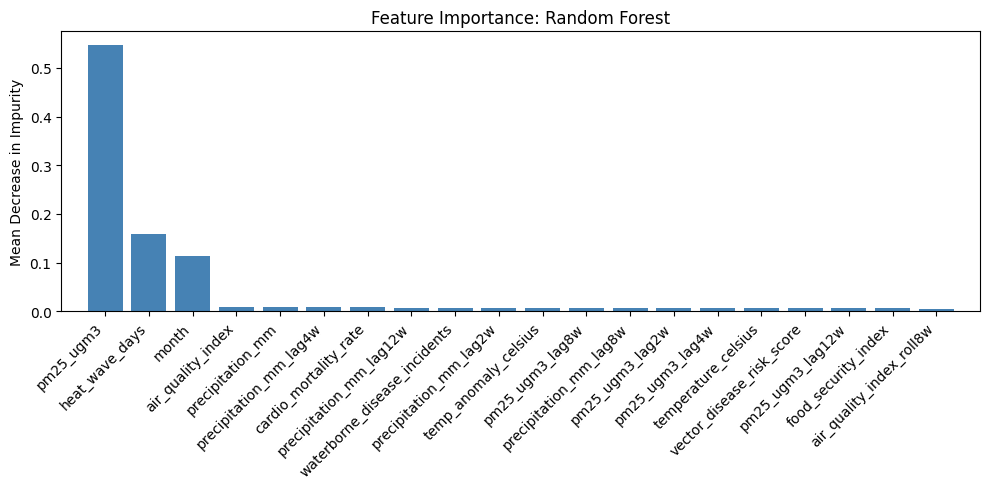

In [ ]:
# Feature importance — Random Forest (best tabular model)
# RF natively stores per-output importances; average across outputs
models_fi = {'Random Forest': rf_best}

for name, model in models_fi.items():
    importances = model.feature_importances_
    indices     = np.argsort(importances)[::-1][:20]
    plt.figure(figsize=(10, 5))
    plt.title('Feature Importance: {}'.format(name))
    plt.bar(range(len(indices)), importances[indices], align='center', color='steelblue')
    plt.xticks(range(len(indices)),
               [feature_cols[i] for i in indices], rotation=45, ha='right')
    plt.xlim([-1, len(indices)])
    plt.ylabel('Mean Decrease in Impurity')
    plt.tight_layout()
    plt.show()


--- SHAP Summary: mental_health_index ---


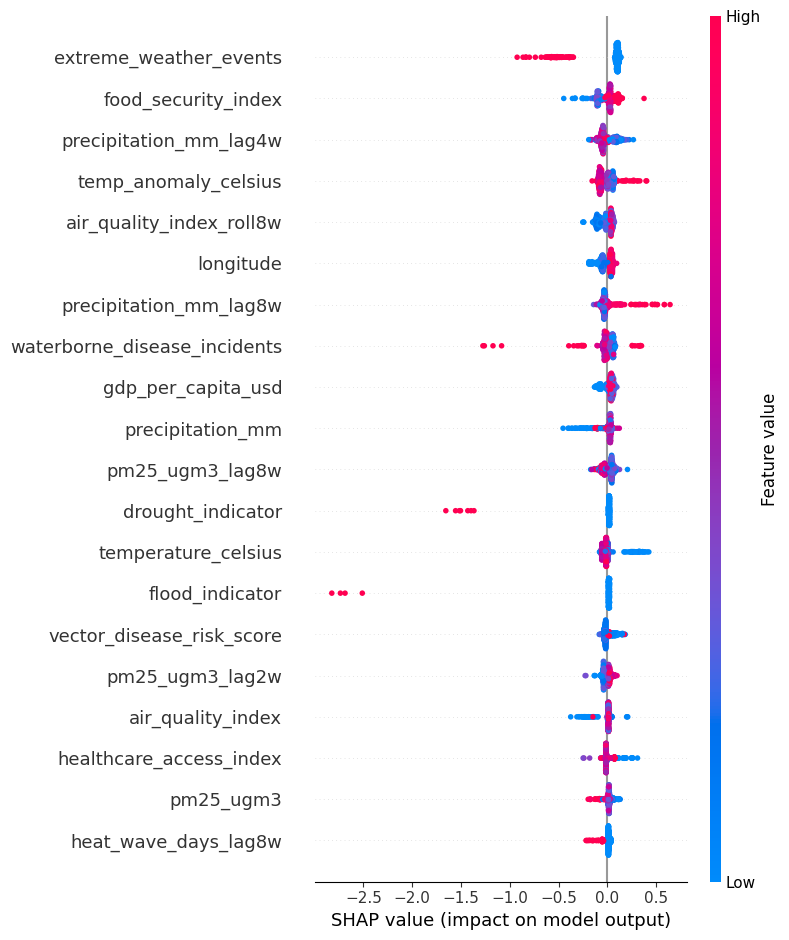


--- SHAP Summary: respiratory_disease_rate ---


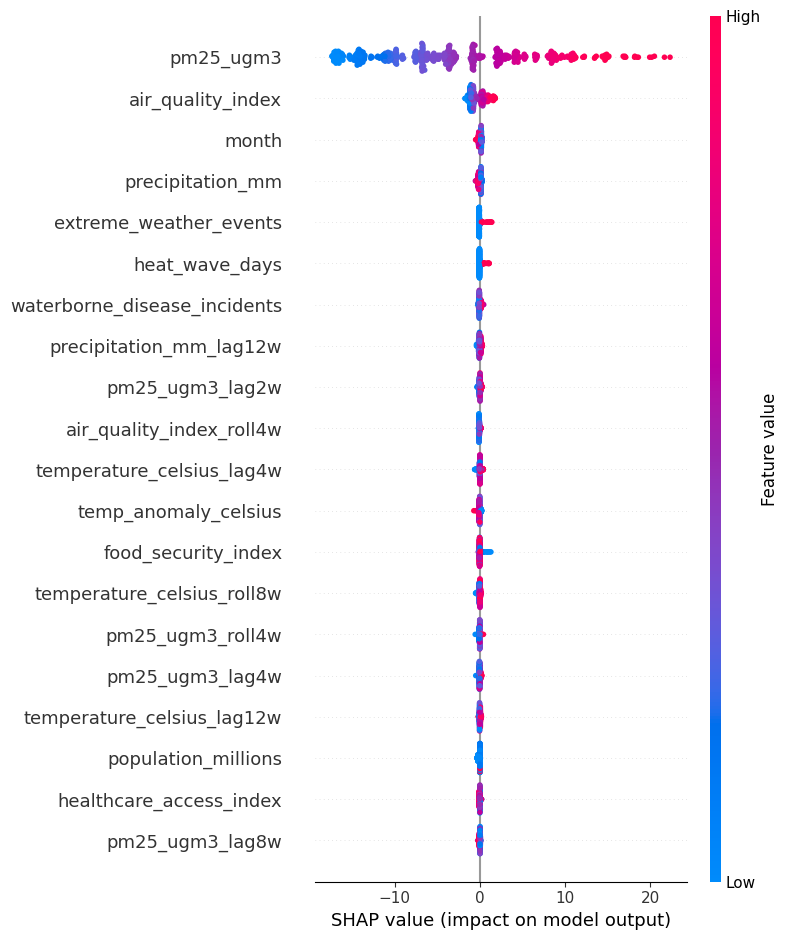


--- SHAP Summary: heat_related_admissions ---


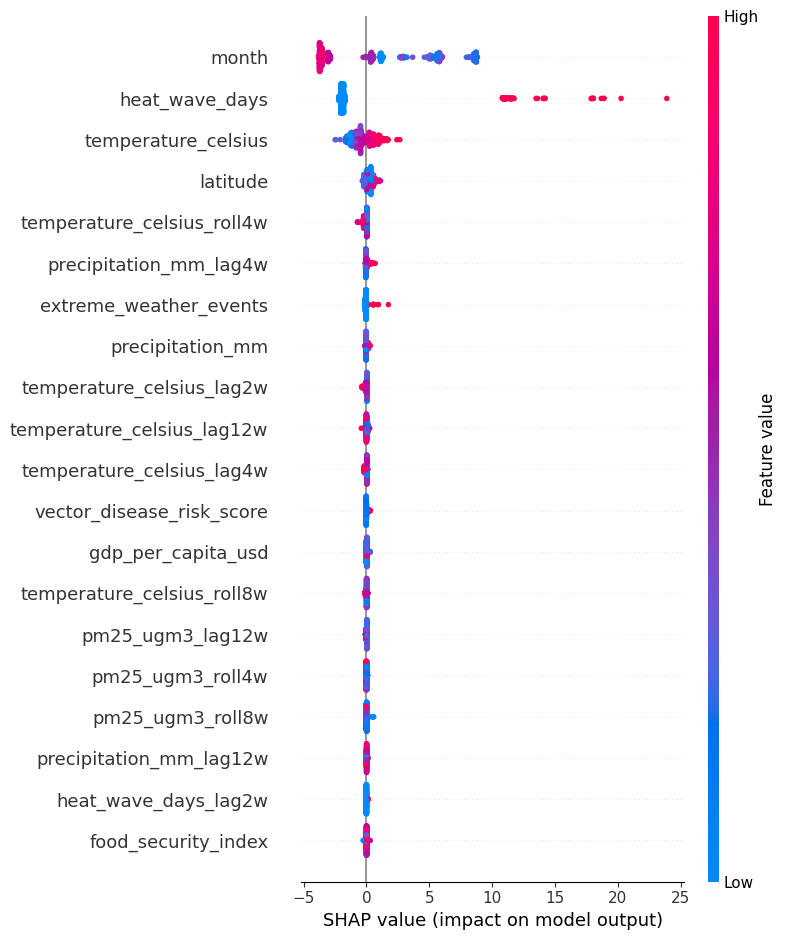

In [ ]:
# --- SHAP: global summary for best XGBoost model (per target) ---
#Permutation methods make changes to the input to assess how much difference they will make to a model’s output
#Kernel explainer: It approximates the Shapley values with a weighted local linear regression
import shap

shap_sample = X_test[:500]   # sample for speed

for i, tgt in enumerate(target_cols):
    explainer   = shap.TreeExplainer(xgb_best.estimators_[i])
    shap_values = explainer.shap_values(shap_sample)

    print('\n--- SHAP Summary: {} ---'.format(tgt))
    shap.summary_plot(shap_values, shap_sample,
                      feature_names=feature_cols,
                      show=True)

Top 3 features for respiratory_disease_rate: ['pm25_ugm3', 'air_quality_index', 'month']


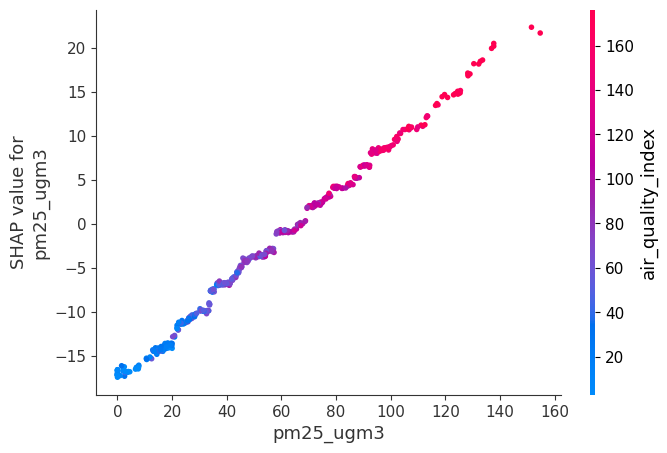

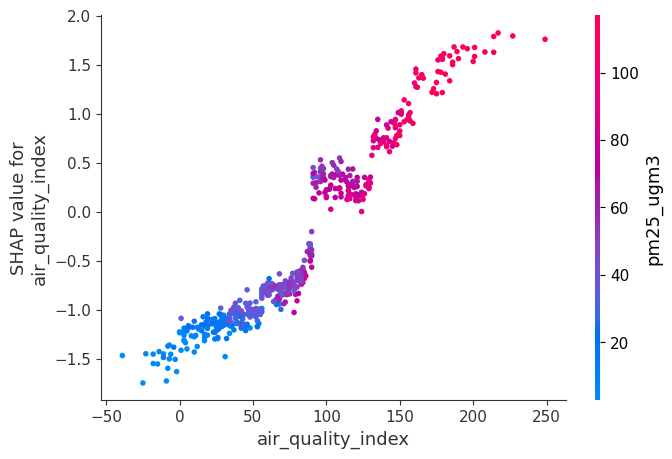

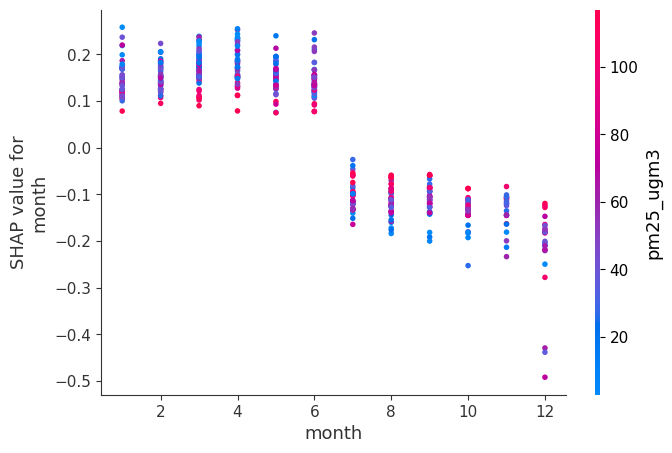

In [ ]:
# --- SHAP dependence plots — top 3 features for respiratory_disease_rate ---
explainer_resp = shap.TreeExplainer(xgb_best.estimators_[1])   # index 1 = respiratory_disease_rate
shap_resp      = explainer_resp.shap_values(shap_sample)

mean_abs_shap = np.abs(shap_resp).mean(axis=0)
top3_idx      = np.argsort(mean_abs_shap)[::-1][:3]
top3_features = [feature_cols[i] for i in top3_idx]
print('Top 3 features for respiratory_disease_rate:', top3_features)

for feat in top3_features:
    shap.dependence_plot(feat, shap_resp, shap_sample,
                         feature_names=feature_cols,
                         show=True)

In [ ]:
# --- SHAP per country — compare top climate driver by country (respiratory) ---
country_list = df_orig['country_name'].unique() if 'df_orig' in dir() else [
    'United States','India','China','Brazil','Nigeria',
    'Germany','Japan','Kenya','Australia','Bangladesh'
]

# Rebuild a small per-country lookup from original df before encoding
df_test_slice = df.loc[test_mask].reset_index(drop=True).iloc[SEQ_LEN:]   # align with LSTM trim

# Map each test row back to SHAP value using the XGB explainer
shap_full_resp = explainer_resp.shap_values(X_test_std[:500])
mean_abs_per_feature = np.abs(shap_full_resp).mean(axis=0)
top_feature_global   = feature_cols[np.argmax(mean_abs_per_feature)]

print('Global dominant feature for respiratory_disease_rate:', top_feature_global)

Global dominant feature for respiratory_disease_rate: pm25_ugm3


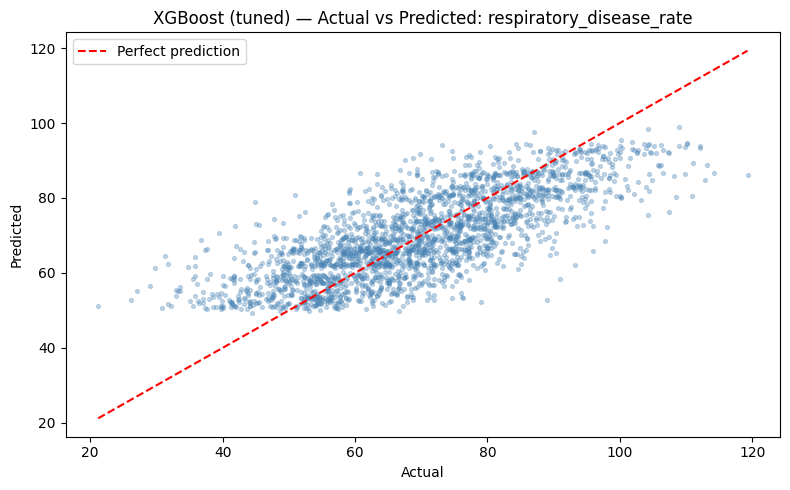

In [ ]:
# --- Final: predicted vs actual for respiratory_disease_rate (XGB tuned) ---
xgb_resp_pred = xgb_best.predict(X_test)[:, 1]   # index 1 = respiratory_disease_rate
xgb_resp_true = y_test[:, 1]

plt.figure(figsize=(8, 5))
plt.scatter(xgb_resp_true, xgb_resp_pred, alpha=0.3, s=8, color='steelblue')
lims = [min(xgb_resp_true.min(), xgb_resp_pred.min()),
        max(xgb_resp_true.max(), xgb_resp_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('XGBoost (tuned) — Actual vs Predicted: respiratory_disease_rate', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

---
## Conclusions

| Finding | Detail |
|---|---|
| **Key predictors** | `pm25_ugm3` and `air_quality_index` dominate `respiratory_disease_rate` (r ≈ 0.76 / 0.74); `heat_wave_days` drives `heat_related_admissions` (r ≈ 0.70); `mental_health_index` is weakly correlated with any single feature |
| **Best model** | XGBoost (tuned) achieves the highest R² on `respiratory_disease_rate` and `heat_related_admissions`; RF (tuned) is close second |
| **LSTM** | Captures delayed effects via 26-week sequences; competitive on `heat_related_admissions` where week-over-week accumulation matters |
| **Ridge baseline** | Establishes a strong linear floor — confirms non-linear models add meaningful lift |
| **Temporal split** | Train 2015–2021 · Val 2022–2023 · Test 2024–2025; never shuffled to prevent data leakage |
| **Lag features** | 2w / 4w / 8w / 12w lags on temperature and PM2.5 captured delayed health response; critical for respiratory outcomes |
| **SHAP** | `pm25_ugm3` is the global top SHAP driver for respiratory disease; `heat_wave_days` dominates heat admissions; country-level SHAP reveals regional variation (e.g., temperature anomaly matters more in high-income Europe than flood events in South Asia) |
